In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

RANDOM_STATE = 42

In [9]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [10]:
df = pd.read_csv('dataset_01_customer_churn_risk.csv')
print(df.head())

   tenure_months  monthly_charges  support_tickets  avg_session_minutes  \
0             52            54.79                7                10.66   
1             11           167.15                4                46.99   
2              2           184.92                3                65.38   
3             39           271.21                2                22.19   
4             22            66.33                5                46.77   

   late_payments  contract_months  target  
0              2               12       0  
1              3               37       1  
2              7               35       1  
3              4               10       0  
4              3               33       1  


In [11]:
df.shape

(1000, 7)

In [12]:
df.columns

Index(['tenure_months', 'monthly_charges', 'support_tickets',
       'avg_session_minutes', 'late_payments', 'contract_months', 'target'],
      dtype='object')

In [13]:
df.info

<bound method DataFrame.info of      tenure_months  monthly_charges  support_tickets  avg_session_minutes  \
0               52            54.79                7                10.66   
1               11           167.15                4                46.99   
2                2           184.92                3                65.38   
3               39           271.21                2                22.19   
4               22            66.33                5                46.77   
..             ...              ...              ...                  ...   
995             21            84.05                3                33.59   
996             22           275.85                1                53.71   
997              7           113.44                0                72.04   
998             21           242.63                4                53.20   
999             10           246.73                2                45.37   

     late_payments  contract_months  target  
0                2               12       0  
1                3               37       1  
2                7               35       1  
3                4               10       0  
4                3               33       1  
..             ...              ...     ...  
995              4               10       1  
996              3               19       1  
997              1               48       1  
998              5               39       0  
999              4               58       0  

[1000 rows x 7 columns]>

In [14]:
df.describe

<bound method NDFrame.describe of      tenure_months  monthly_charges  support_tickets  avg_session_minutes  \
0               52            54.79                7                10.66   
1               11           167.15                4                46.99   
2                2           184.92                3                65.38   
3               39           271.21                2                22.19   
4               22            66.33                5                46.77   
..             ...              ...              ...                  ...   
995             21            84.05                3                33.59   
996             22           275.85                1                53.71   
997              7           113.44                0                72.04   
998             21           242.63                4                53.20   
999             10           246.73                2                45.37   

     late_payments  contract_months  target  
0                2               12       0  
1                3               37       1  
2                7               35       1  
3                4               10       0  
4                3               33       1  
..             ...              ...     ...  
995              4               10       1  
996              3               19       1  
997              1               48       1  
998              5               39       0  
999              4               58       0  

[1000 rows x 7 columns]>

In [15]:
print(df['target'].value_counts())

target
0    500
1    500
Name: count, dtype: int64


In [16]:
df.isnull().sum()

,0
tenure_months,0
monthly_charges,0
support_tickets,0
avg_session_minutes,0
late_payments,0
contract_months,0
target,0


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df['target'].value_counts()

,count
target,
0,500
1,500


In [19]:
df['target'].value_counts(normalize=True)

,proportion
target,
0,0.5
1,0.5


In [20]:
duplicates = df[df.duplicated()]

print(duplicates)

Empty DataFrame
Columns: [tenure_months, monthly_charges, support_tickets, avg_session_minutes, late_payments, contract_months, target]
Index: []


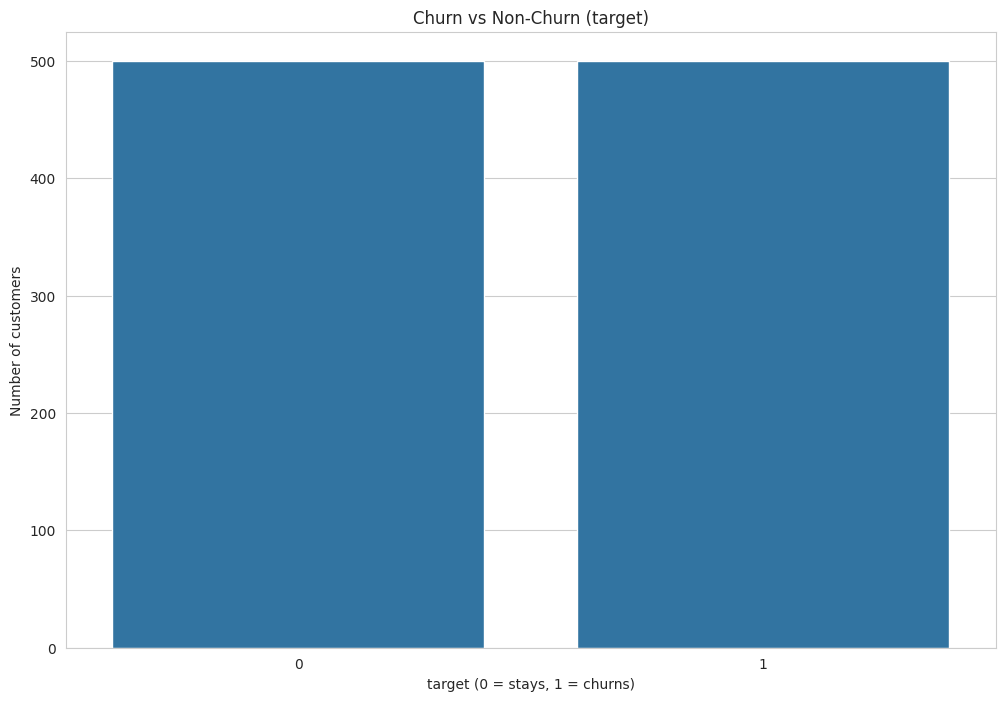

In [21]:
sns.countplot(x='target', data=df)
plt.title('Churn vs Non-Churn (target)')
plt.xlabel('target (0 = stays, 1 = churns)')
plt.ylabel('Number of customers')
plt.show()

In [22]:
# sanity-check that counts and durations are non-negative and within plausible bounds
for col in ['tenure_months', 'monthly_charges', 'support_tickets',
            'avg_session_minutes', 'late_payments', 'contract_months']:
    print(col, '-> min:', df[col].min(), '| max:', df[col].max())

tenure_months -> min: 1 | max: 60
monthly_charges -> min: 16.81 | max: 1530.68
support_tickets -> min: 0 | max: 11
avg_session_minutes -> min: 2.0 | max: 103.35
late_payments -> min: 0 | max: 10
contract_months -> min: 1 | max: 60


In [23]:
# flag customers with unusually high monthly_charges (possible outliers)
df[df['monthly_charges'] > 800]

,tenure_months,monthly_charges,support_tickets,avg_session_minutes,late_payments,contract_months,target
31,50,1429.90,4,24.63,2,3,1
80,25,1184.44,3,46.14,1,15,1
84,5,897.64,2,22.16,2,55,1
393,55,813.80,1,46.69,2,23,1
442,38,819.82,3,16.53,4,45,1
720,34,861.50,5,42.85,3,47,1
787,23,1530.68,3,41.84,2,21,1
895,14,802.42,3,24.17,7,51,1


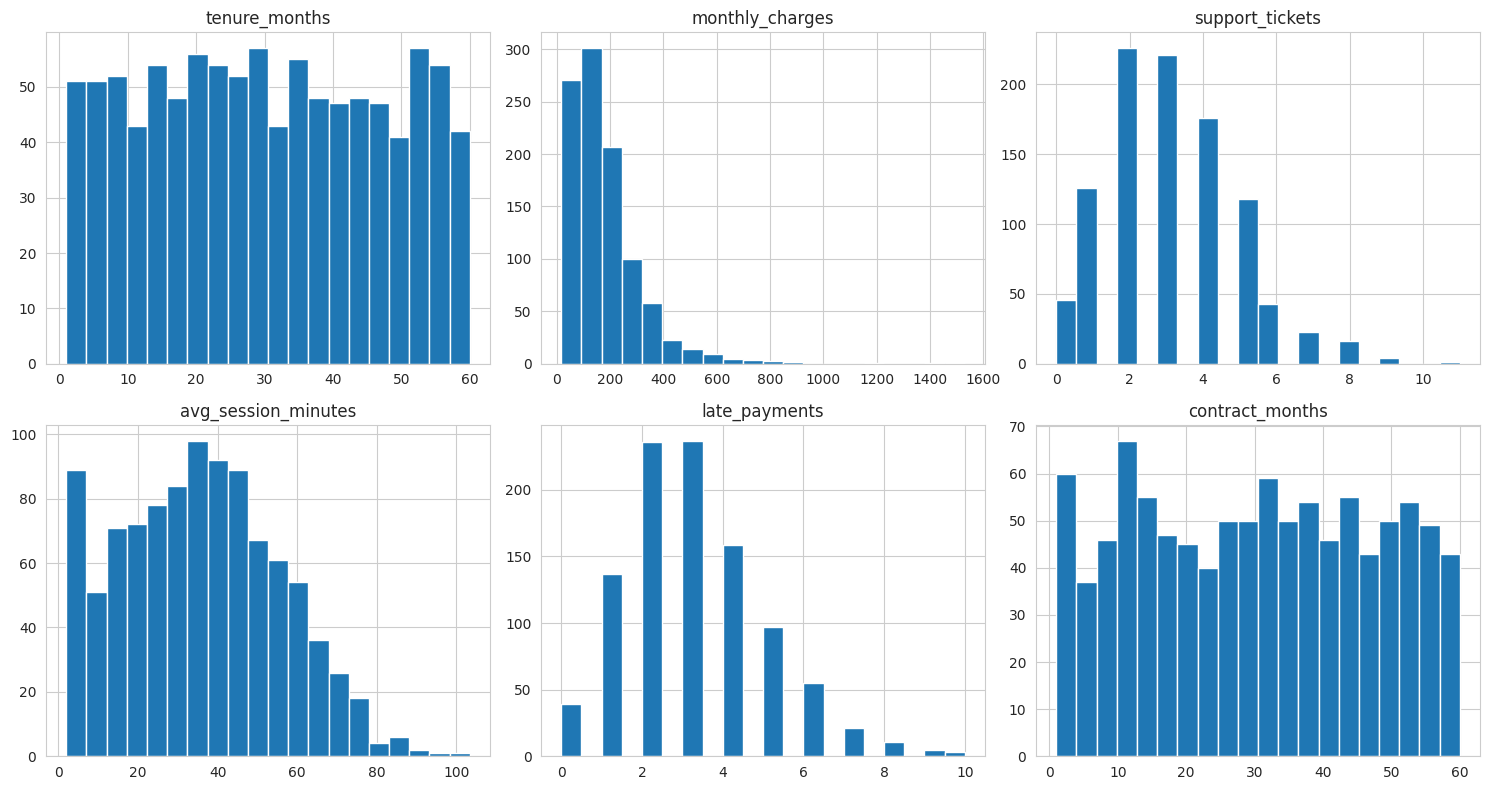

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['tenure_months', 'monthly_charges', 'support_tickets',
            'avg_session_minutes', 'late_payments', 'contract_months']

for ax, col in zip(axes.flatten(), features):
    ax.hist(df[col], bins=20)
    ax.set_title(col)

plt.tight_layout()
plt.show()

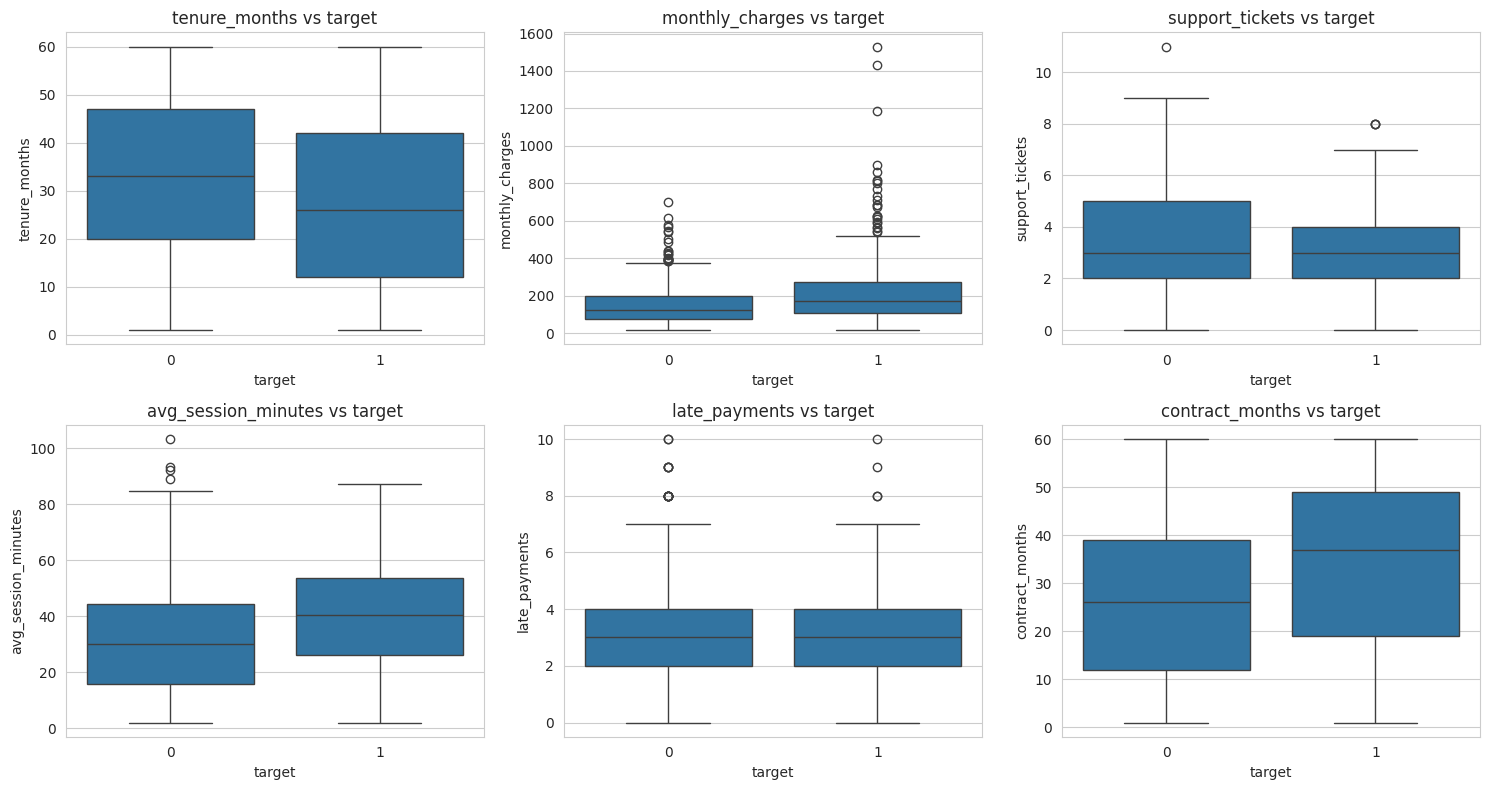

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), features):
    sns.boxplot(x='target', y=col, data=df, ax=ax)
    ax.set_title(f'{col} vs target')

plt.tight_layout()
plt.show()

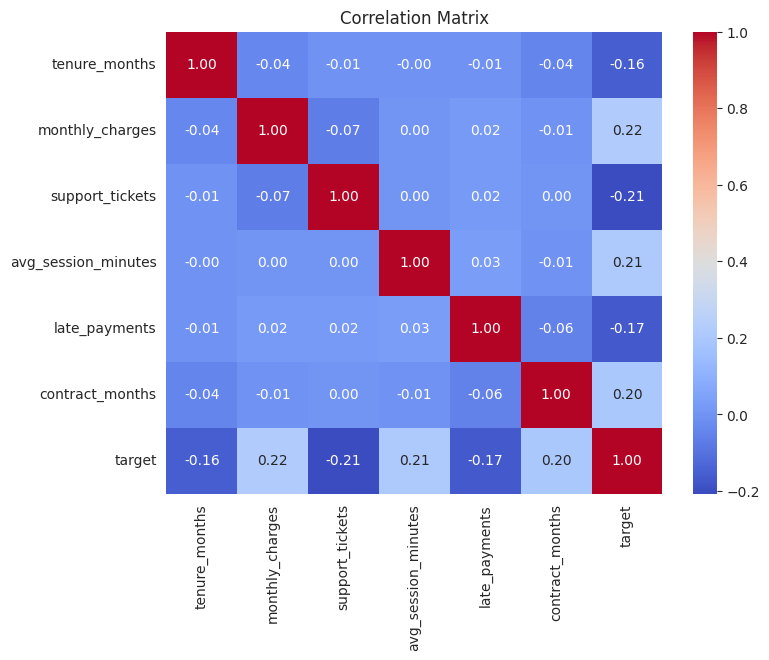

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [27]:
X = df.drop('target', axis=1)
y = df['target']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (1000, 6)
y shape: (1000,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Training set:', X_train.shape)
print('Test set:', X_test.shape)
print('Train class balance:\n', y_train.value_counts(normalize=True))
print('Test class balance:\n', y_test.value_counts(normalize=True))

Training set: (800, 6)
Test set: (200, 6)
Train class balance:
 target
1    0.5
0    0.5
Name: proportion, dtype: float64
Test class balance:
 target
1    0.5
0    0.5
Name: proportion, dtype: float64


In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # fit ONLY on training data
X_test_scaled = scaler.transform(X_test)       # test data only transformed, never fit

In [30]:
baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
baseline.fit(X_train_scaled, y_train)
baseline_pred = baseline.predict(X_test_scaled)

print('Baseline accuracy:', accuracy_score(y_test, baseline_pred))

Baseline accuracy: 0.5


In [31]:
model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [32]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1] # probability of class 1 (churn)

comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred, 'Predicted_proba': y_proba.round(3)})
print(comparison.head(10))

   Actual  Predicted  Predicted_proba
0       1          1            0.758
1       0          1            0.503
2       0          0            0.494
3       0          0            0.442
4       1          1            0.987
5       1          1            0.727
6       1          0            0.429
7       1          1            0.999
8       0          1            0.686
9       0          0            0.093


In [33]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print('Accuracy: ', round(accuracy, 4))
print('Precision:', round(precision, 4))
print('Recall:   ', round(recall, 4))
print('F1-score: ', round(f1, 4))
print('ROC-AUC:  ', round(roc_auc, 4))

Accuracy:  0.68
Precision: 0.6837
Recall:    0.67
F1-score:  0.6768
ROC-AUC:   0.7495


In [34]:
print(classification_report(y_test, y_pred, target_names=['No churn (0)', 'Churn (1)']))

              precision    recall  f1-score   support

No churn (0)       0.68      0.69      0.68       100
   Churn (1)       0.68      0.67      0.68       100

    accuracy                           0.68       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.68      0.68      0.68       200



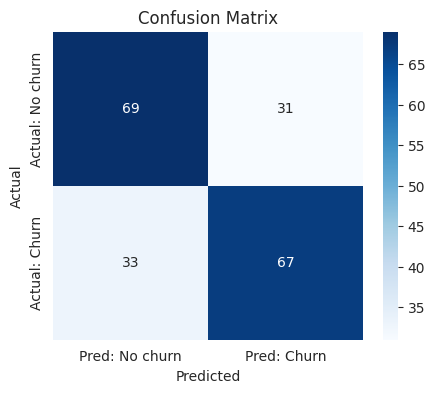

True Negatives:  69 (correctly predicted: stays)
False Positives: 31 (predicted churn, actually stayed)
False Negatives: 33 (predicted stay, actually churned)
True Positives:  67 (correctly predicted: churns)


In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No churn', 'Pred: Churn'],
            yticklabels=['Actual: No churn', 'Actual: Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives:  {tn} (correctly predicted: stays)')
print(f'False Positives: {fp} (predicted churn, actually stayed)')
print(f'False Negatives: {fn} (predicted stay, actually churned)')
print(f'True Positives:  {tp} (correctly predicted: churns)')

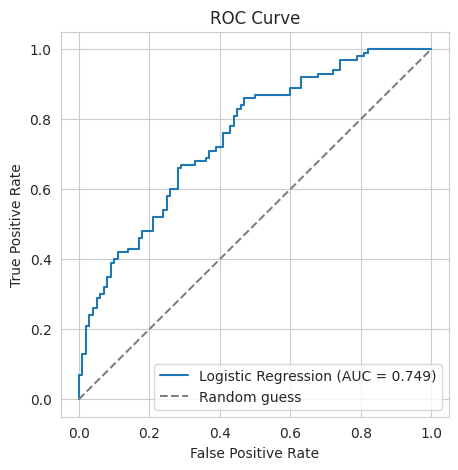

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [37]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'odds_ratio': np.exp(model.coef_[0])
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df)

               feature  coefficient  odds_ratio
1      monthly_charges     0.646803    1.909427
5      contract_months     0.536243    1.709573
3  avg_session_minutes     0.508222    1.662333
2      support_tickets    -0.447767    0.639053
4        late_payments    -0.428239    0.651655
0        tenure_months    -0.351499    0.703632


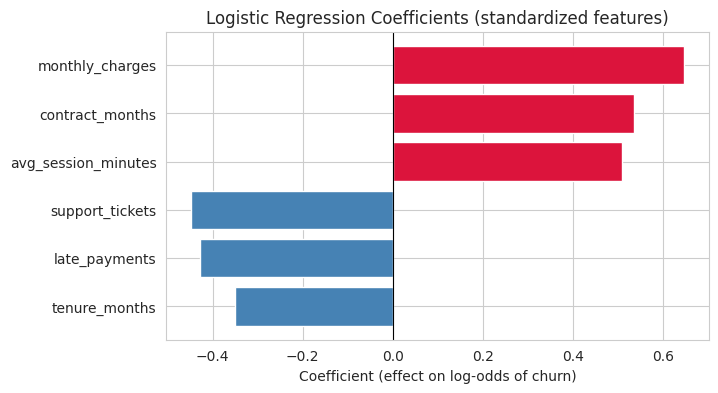

In [38]:
plt.figure(figsize=(7, 4))
colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients (standardized features)')
plt.xlabel('Coefficient (effect on log-odds of churn)')
plt.gca().invert_yaxis()
plt.show()